In [1]:
#Libraries importation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset
cleaned_path = '../data/cleaned_train_data.csv'
df = pd.read_csv(cleaned_path)

In [3]:
#Separate features and target variable
target = 'Claim'
X = df.drop(columns=[target])
y = df[target]

In [4]:
#Separate Data in Numerical and Categorical Columns
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

### Univariate Analysis - Numerical Data

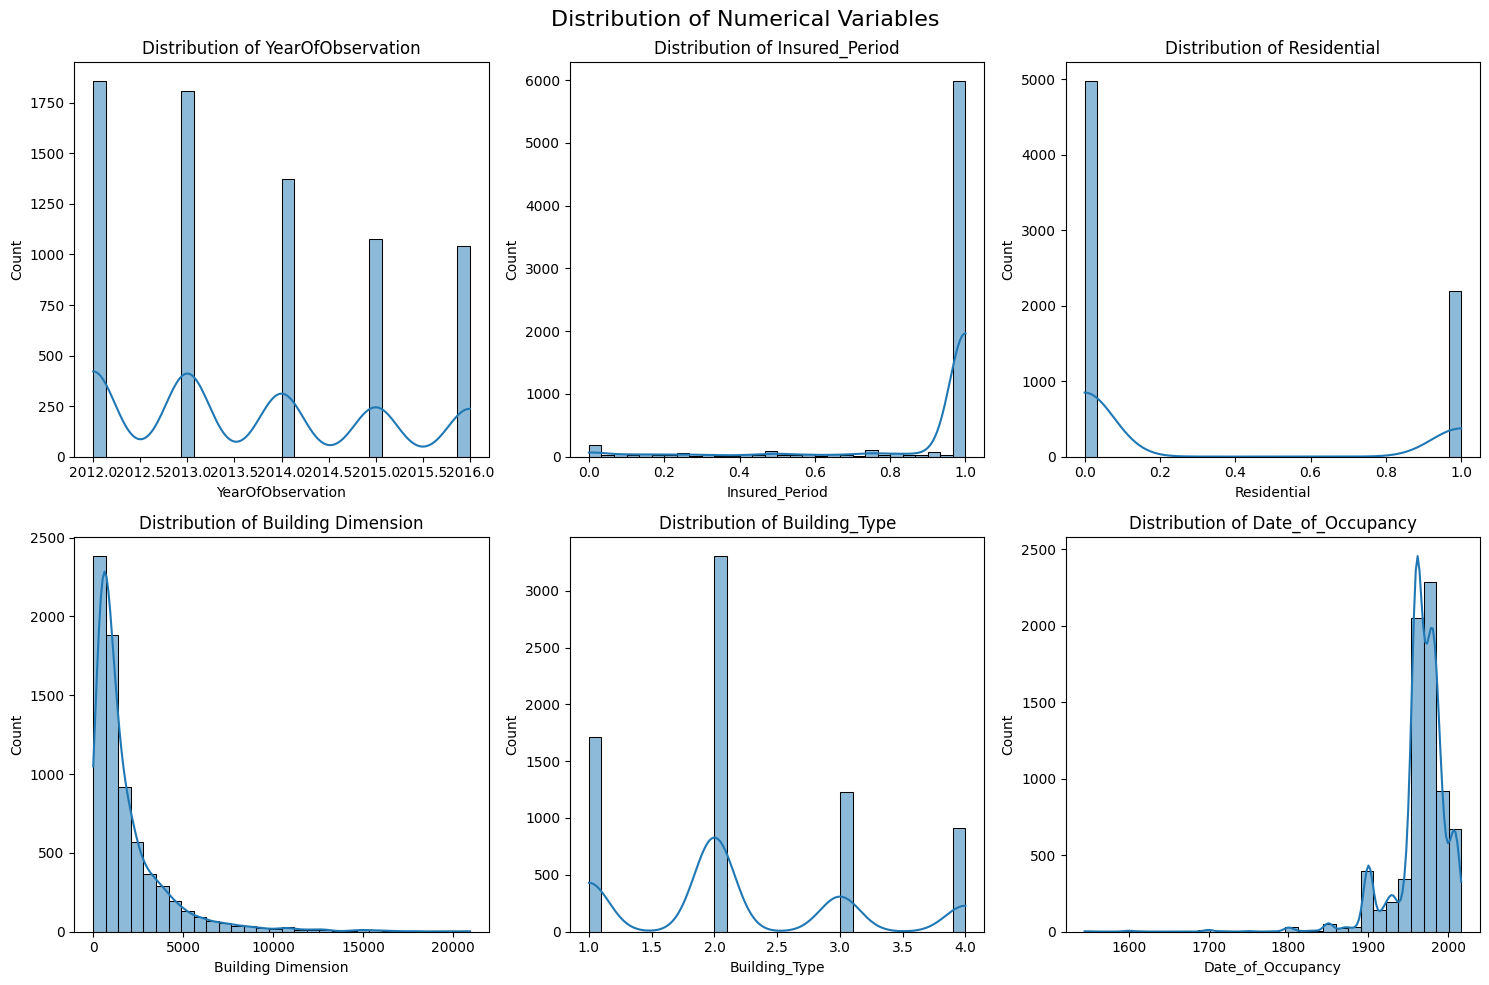

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Numerical Variables', fontsize=16)

axes_flat = [axes[i, j] for i in range(2) for j in range(3)]

for ax, col in zip(axes_flat, numerical_cols):
    sns.histplot(X[col], kde=True, bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### Univariate Analysis - Categorical Data

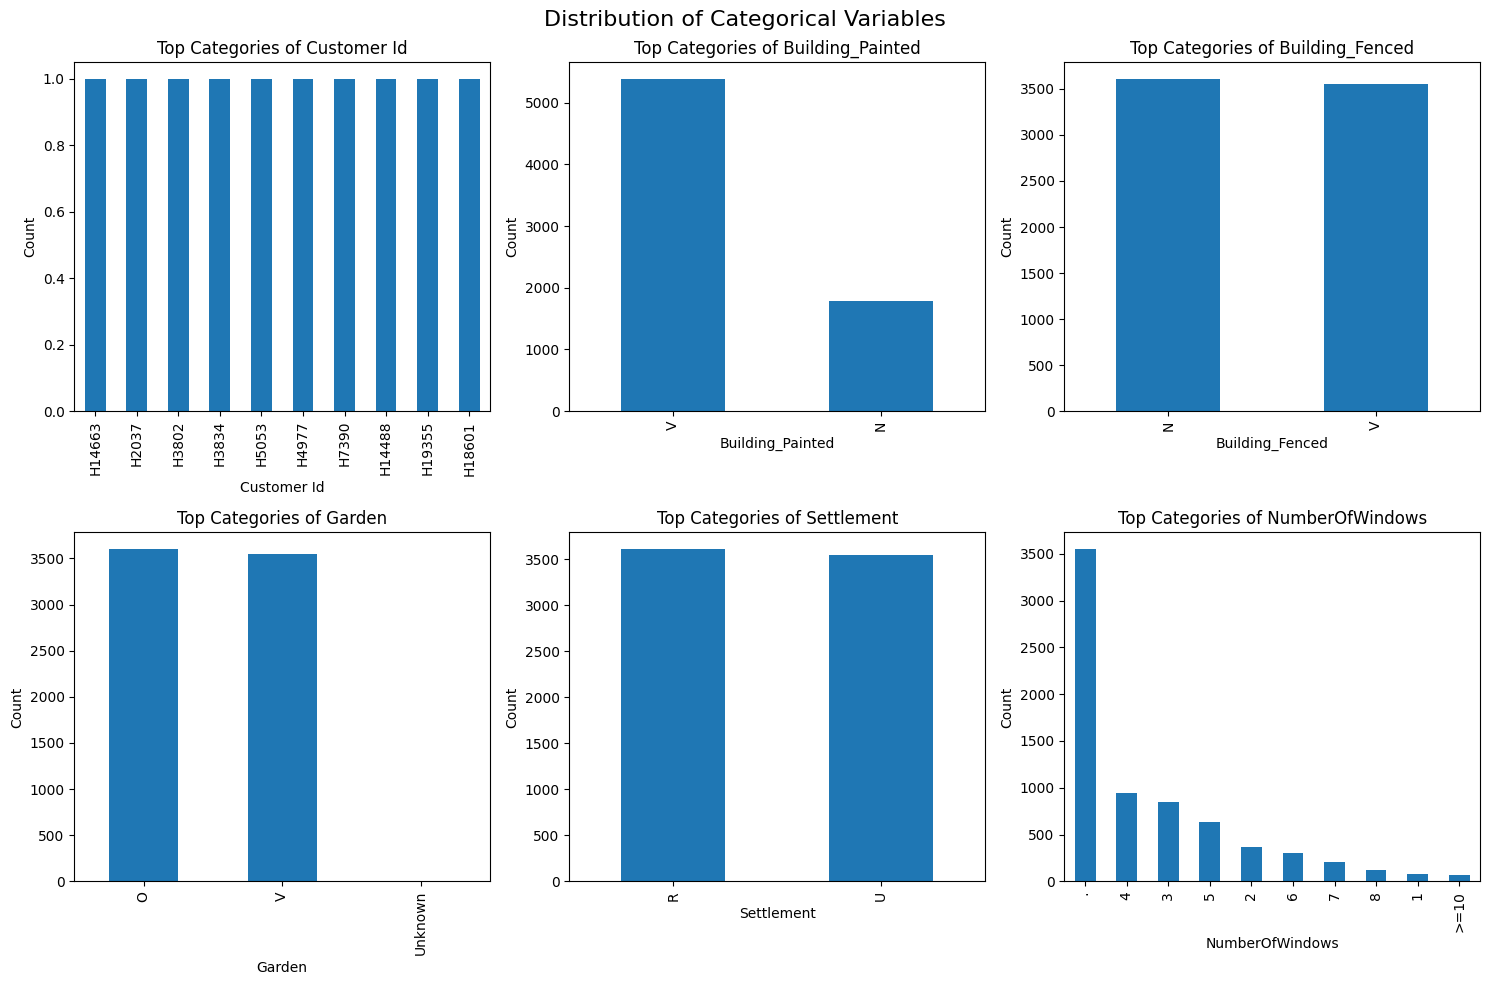

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

axes_flat = [axes[i, j] for i in range(2) for j in range(3)]

for ax, col in zip(axes_flat, categorical_cols):
    X[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(f'Top Categories of {col}')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

### Bivariate Analysis - Numerical Data vs Target

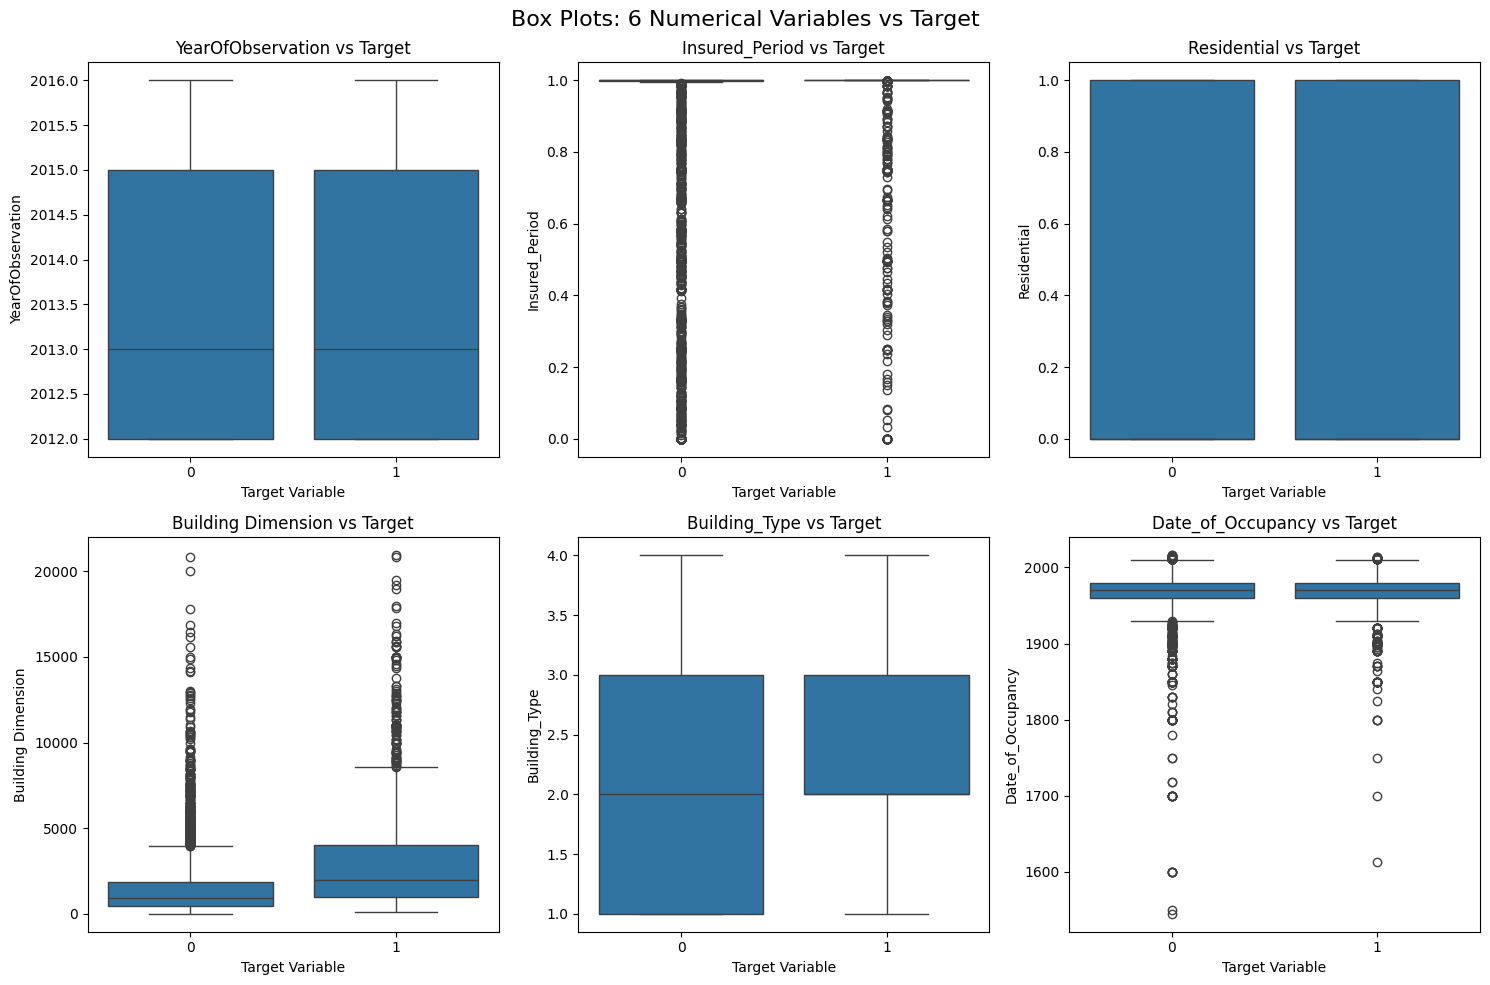

In [7]:
plot_cols = numerical_cols

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Box Plots: {len(plot_cols)} Numerical Variables vs Target', fontsize=16)

axes_flat = axes.ravel()

for idx, col in enumerate(plot_cols):
    sns.boxplot(x=y, y=X[col], ax=axes_flat[idx])
    axes_flat[idx].set_title(f'{col} vs Target', fontsize=12)
    axes_flat[idx].set_xlabel('Target Variable')
    axes_flat[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

## Correlation Heapmap of numerical data

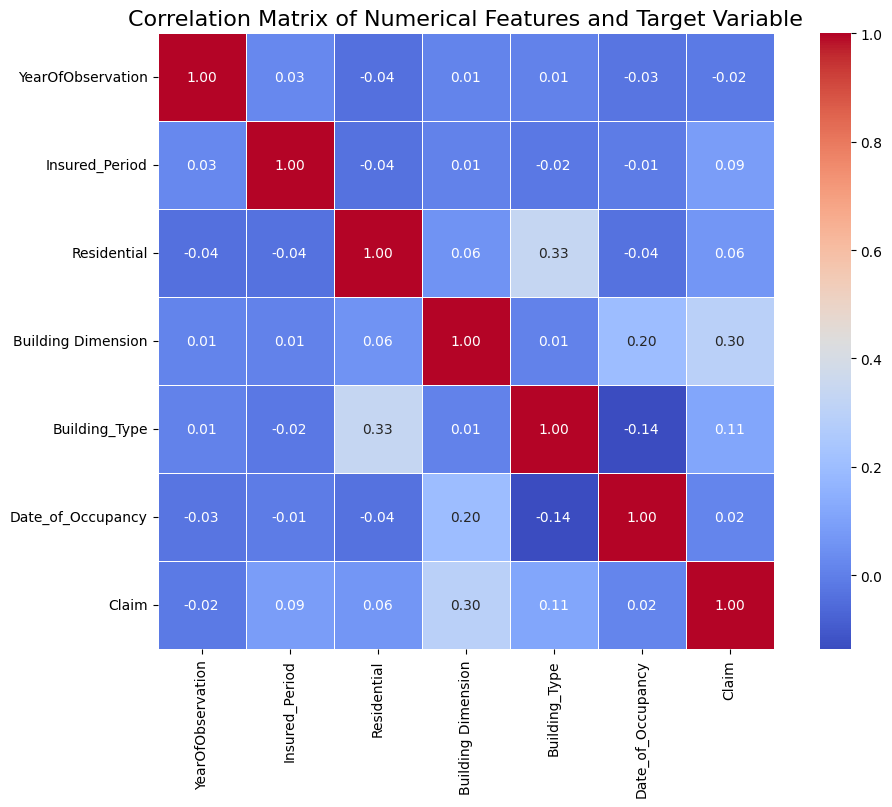

In [8]:
corr_matrix = df[numerical_cols + [target]].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features and Target Variable', fontsize=16)
plt.show()

Let's convert all the categorical feature to numeric and visualise the heatmap with all the features to see the correlation

In [9]:
from sklearn.preprocessing import LabelEncoder

df_numeric= df.copy()

le = LabelEncoder()
for col in categorical_cols:
    df_numeric[col] = le.fit_transform(df_numeric[col])

corr_matrix_full = df_numeric.corr()

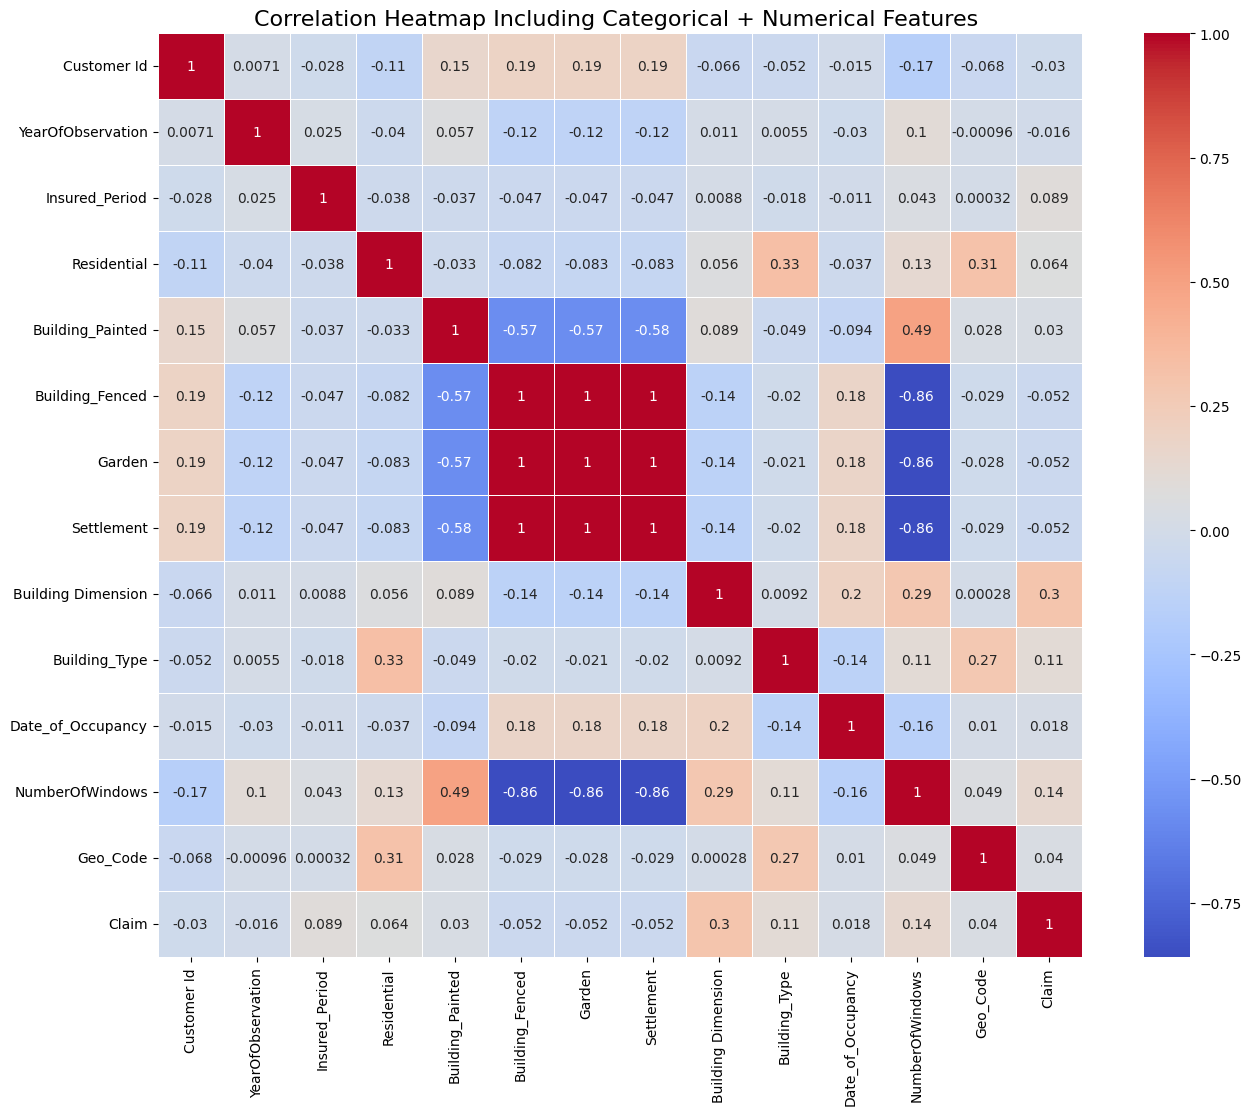

In [12]:
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix_full,
    annot=True,
    cmap='coolwarm',
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap Including Categorical + Numerical Features ', fontsize=16)
plt.show()

We can based on the correlation matrix perform a feature selection with a specified threshold and change gradualy to see the model performance